# GHCN Climate Zone Discovery
Group: Mica Dizo, Caitlyn Lee, and Dianne Yumol

Final Project for CSCI 273 - Big Data Processing

Objective: Can big-data ML tools automatically rediscover the world's climate zones from raw weather observations with no geographic labels?

## 1. Install dependencies

In [ ]:
!pip install pyspark --quiet

## 2. Authenticate with Google Cloud

In [ ]:
from google.colab import auth
auth.authenticate_user()
print("Authenticated ✓")

Authenticated ✓


## 3. Configuration

In [ ]:
GCS_BUCKET  = "csci-273-final-project-climate-zones-partitioned"
GCP_PROJECT = "csci273project01"

GCS_INPUT_PATH  = f"gs://{GCS_BUCKET}/input/climate_data.tar.gz"
GCS_OUTPUT_PATH = f"gs://{GCS_BUCKET}/output/clusters"
LOCAL_TAR_PATH  = "/tmp/climate_data.tar.gz"

print("Input :", GCS_INPUT_PATH)
print("Output:", GCS_OUTPUT_PATH)

Input : gs://csci-273-final-project-climate-zones-partitioned/input/climate_data.tar.gz
Output: gs://csci-273-final-project-climate-zones-partitioned/output/clusters


## 4. Imports

In [ ]:
import os
import tarfile
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, floor, rand, row_number
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

## 5. Start Spark with the GCS connector
The [GCS Hadoop connector](https://github.com/GoogleCloudDataproc/hadoop-connectors/tree/master/gcs) JAR teaches Spark how to read and write `gs://` paths using your OAuth credentials.

In [ ]:
# Download the GCS Hadoop connector
GCS_CONNECTOR_JAR = "/tmp/gcs-connector-hadoop3-latest.jar"

if not os.path.exists(GCS_CONNECTOR_JAR):
    print("Downloading GCS Hadoop connector …")
    subprocess.run([
        "wget", "-q", "-O", GCS_CONNECTOR_JAR,
        "https://storage.googleapis.com/hadoop-lib/gcs/gcs-connector-hadoop3-latest.jar"
    ], check=True)
    print("Downloaded ✓")

# Get an OAuth access token from the Colab credential store
import google.auth
import google.auth.transport.requests

creds, _ = google.auth.default()
creds.refresh(google.auth.transport.requests.Request())
ACCESS_TOKEN = creds.token

spark = (
    SparkSession.builder
    .appName("ClimateZoneDiscovery")
    .master("local[*]")                           # use all Colab CPU cores
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "50")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.jars", GCS_CONNECTOR_JAR)
    .config("spark.hadoop.fs.gs.impl",
            "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem")
    .config("spark.hadoop.fs.AbstractFileSystem.gs.impl",
            "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFS")
    .config("spark.hadoop.fs.gs.project.id", GCP_PROJECT)
    .config("spark.hadoop.fs.gs.auth.type", "ACCESS_TOKEN_PROVIDER")
    .config("spark.hadoop.google.cloud.auth.service.account.enable", "false")
    .config("spark.hadoop.fs.gs.fixed.access.token", ACCESS_TOKEN)
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Downloaded ✓
Spark version: 4.0.2


## 6. Copy dataset from GCS to local `/tmp`


In [ ]:
import random

random.seed(42)

print(f"Copying {GCS_INPUT_PATH}  →  {LOCAL_TAR_PATH} …")

result = subprocess.run(
    ["gsutil", "cp", GCS_INPUT_PATH, LOCAL_TAR_PATH],
    capture_output=True, text=True
)

if result.returncode != 0:
    raise RuntimeError(f"gsutil failed:\n{result.stderr}")

print("Download complete ✓")

with tarfile.open(LOCAL_TAR_PATH) as tar:
    all_members = [
        m.name for m in tar.getmembers()
        if m.name.endswith(".csv") and m.isfile()
    ]

members = random.sample(all_members, k=min(200, len(all_members)))

print(f"Total CSVs in archive : {len(all_members):,}")
print(f"Randomly sampled      : {len(members)} stations (seed=42)")

Copying gs://csci-273-final-project-climate-zones-partitioned/input/climate_data.tar.gz  →  /tmp/climate_data.tar.gz …
Download complete ✓
Total CSVs in archive : 129,591
Randomly sampled      : 200 stations (seed=42)


## 7. Process stations in parallel with Spark RDD

In [ ]:
NUM_PARTITIONS = 50

stations_rdd = spark.sparkContext.parallelize(members, NUM_PARTITIONS)

In [ ]:
import os

EXTRACT_DIR = "/tmp/stations"
os.makedirs(EXTRACT_DIR, exist_ok=True)

members_set = set(members)

print("Extracting CSVs in one pass …")
with tarfile.open(LOCAL_TAR_PATH) as tar:
    for member in tar:
        if member.name in members_set and member.isfile():
            tar.extract(member, path=EXTRACT_DIR)

print("Extraction complete ✓")

Extracting CSVs in one pass …


/tmp/ipykernel_3474/2865530022.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(member, path=EXTRACT_DIR)


Extraction complete ✓


In [ ]:
import os

sample_path = os.path.join("/tmp/stations", members[0])
import pandas as pd
df = pd.read_csv(sample_path)
print(df.columns.tolist())
print(df.head(3))

['STATION', 'DATE', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'NAME', 'PRCP', 'PRCP_ATTRIBUTES', 'TMAX', 'TMAX_ATTRIBUTES', 'TMIN', 'TMIN_ATTRIBUTES', 'DAPR', 'DAPR_ATTRIBUTES', 'DATN', 'DATN_ATTRIBUTES', 'DATX', 'DATX_ATTRIBUTES', 'DWPR', 'DWPR_ATTRIBUTES', 'MDPR', 'MDPR_ATTRIBUTES', 'MDTN', 'MDTN_ATTRIBUTES', 'MDTX', 'MDTX_ATTRIBUTES']
       STATION        DATE  LATITUDE  LONGITUDE  ELEVATION  \
0  ASN00041116  1888-04-01  -28.9231   151.9306      875.0   
1  ASN00041116  1888-04-02  -28.9231   151.9306      875.0   
2  ASN00041116  1888-04-03  -28.9231   151.9306      875.0   

                          NAME  PRCP PRCP_ATTRIBUTES  TMAX TMAX_ATTRIBUTES  \
0  WALLANGARRA POST OFFICE, AS   0.0             ,,a   NaN             NaN   
1  WALLANGARRA POST OFFICE, AS   0.0             ,,a   NaN             NaN   
2  WALLANGARRA POST OFFICE, AS   0.0             ,,a   NaN             NaN   

   ...  DATX DATX_ATTRIBUTES  DWPR DWPR_ATTRIBUTES  MDPR MDPR_ATTRIBUTES  \
0  ...   NaN             N

/tmp/ipykernel_3474/4071522164.py:6: DtypeWarning: Columns (15,17,23,25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(sample_path)


In [ ]:
def process_station(member_name):
    import pandas as pd
    import numpy as np
    import os

    path = os.path.join("/tmp/stations", member_name)
    df   = pd.read_csv(path)
    df   = df.dropna(subset=["LATITUDE", "LONGITUDE"])
    if df.empty:
        return None

    # Skip stations missing required columns
    required = ["TMAX", "TMIN", "PRCP"]
    if any(c not in df.columns for c in required):
        return None

    if df["TMAX"].isna().all() or df["TMIN"].isna().all() or df["PRCP"].isna().all():
        return None

    lat = float(df["LATITUDE"].iloc[0])
    lon = float(df["LONGITUDE"].iloc[0])

    # Köppen-like proxy variables
    tmax_mean = df["TMAX"].mean()
    tmin_mean = df["TMIN"].mean()
    tmax_max  = df["TMAX"].max()
    tmin_min  = df["TMIN"].min()
    prcp_mean = df["PRCP"].mean()
    prcp_std  = df["PRCP"].std()
    snwd_mean = df["SNWD"].mean() if "SNWD" in df.columns and not df["SNWD"].isna().all() else 0.0

    temp_range_proxy       = float(tmax_mean - tmin_mean)   #diurnal range
    temp_spread_proxy      = float(tmax_max  - tmin_min)    #annual range
    coldness_proxy         = float(-tmin_mean)              #coldest month proxy
    heat_proxy             = float(tmax_mean)               #warmest month proxy
    precip_wetness_proxy   = float(prcp_mean)               #annual precip proxy
    precip_variability_proxy = float(prcp_std)              #seasonal dry/wet proxy
    snowiness_proxy        = float(snwd_mean)               #snow cover/polar proxy

    values = [
        temp_range_proxy, temp_spread_proxy,
        coldness_proxy, heat_proxy,
        precip_wetness_proxy, precip_variability_proxy,
        snowiness_proxy
    ]

    if any(np.isnan(v) for v in values):
        return None

    return (
        member_name,
        lat, lon,
        temp_range_proxy,
        temp_spread_proxy,
        coldness_proxy,
        heat_proxy,
        precip_wetness_proxy,
        precip_variability_proxy,
        snowiness_proxy
    )

features_rdd = (
    stations_rdd
    .map(process_station)
    .filter(lambda x: x is not None)
)

features_df = spark.createDataFrame(
    features_rdd,
    [
        "station",
        "lat", "lon",
        "temp_range_proxy",
        "temp_spread_proxy",
        "coldness_proxy",
        "heat_proxy",
        "precip_wetness_proxy",
        "precip_variability_proxy",
        "snowiness_proxy"
    ]
)

features_df.show(5)

+---------------+--------+---------+------------------+-----------------+-------------------+------------------+--------------------+------------------------+------------------+
|        station|     lat|      lon|  temp_range_proxy|temp_spread_proxy|     coldness_proxy|        heat_proxy|precip_wetness_proxy|precip_variability_proxy|   snowiness_proxy|
+---------------+--------+---------+------------------+-----------------+-------------------+------------------+--------------------+------------------------+------------------+
|ASN00041116.csv|-28.9231| 151.9306|120.30698873659587|            426.0| -84.78738770477365|205.09437644136952|  19.253011528930074|       66.76422690691636|               0.0|
|USC00264501.csv|36.32083|-115.6725|158.91515303781705|            583.0| 21.106361829025843| 137.8087912087912|  16.588082420642287|       77.84126849632347| 54.83086053412463|
|FIE00142366.csv| 60.4331|  26.3667| 84.60667556742324|            690.0| 1.1388518024032044| 83.4678237650200

## 8. Feature assembly + scaling using Köppen-Like Proxy Variables

In [ ]:
INPUT_COLS = [
    "temp_range_proxy",
    "temp_spread_proxy",
    "coldness_proxy",
    "heat_proxy",
    "precip_wetness_proxy",
    "precip_variability_proxy",
    "snowiness_proxy"
]

assembler = VectorAssembler(inputCols=INPUT_COLS, outputCol="raw_features")
assembled = assembler.transform(features_df)

scaler  = StandardScaler(
    inputCol="raw_features", outputCol="features",
    withMean=True, withStd=True
)
dataset = scaler.fit(assembled).transform(assembled)

## 9. KMeans clustering

In [ ]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(featuresCol="features")
results   = {}

for K in range(2, 7):
    kmeans   = KMeans(k=K, seed=1, featuresCol="features")
    model    = kmeans.fit(dataset)
    clusters = model.transform(dataset)
    silhouette = evaluator.evaluate(clusters)
    results[K] = {"model": model, "clusters": clusters, "silhouette": silhouette}
    print(f"K={K}  Silhouette={silhouette:.4f}")

# Pick the best K by highest silhouette score
best_K    = max(results, key=lambda k: results[k]["silhouette"])
clusters  = results[best_K]["clusters"]
print(f"\nBest K={best_K}  Silhouette={results[best_K]['silhouette']:.4f}")

K=2  Silhouette=0.4698
K=3  Silhouette=0.3556
K=4  Silhouette=0.2956
K=5  Silhouette=0.3808
K=6  Silhouette=0.4165

Best K=2  Silhouette=0.4698


## 10. Cluster summary statistics

In [ ]:
from pyspark.sql.functions import avg, count

best_clusters = results[best_K]["clusters"]

summary = best_clusters.groupBy("prediction").agg(
    count("station").alias("num_stations"),

    avg("heat_proxy").alias("avg_heat"),                           # ↔ warmest month (TMAX_MEAN)
    avg("coldness_proxy").alias("avg_coldness"),                   # ↔ coldest month (-TMIN_MEAN)
    avg("temp_range_proxy").alias("avg_diurnal_range"),            # ↔ diurnal range (TMAX_MEAN - TMIN_MEAN)
    avg("temp_spread_proxy").alias("avg_annual_temp_spread"),      # ↔ annual range (TMAX_MAX - TMIN_MIN)

    avg("precip_wetness_proxy").alias("avg_precip"),               # ↔ annual precipitation (PRCP_MEAN)
    avg("precip_variability_proxy").alias("avg_precip_variability"), # ↔ seasonal dry/wet (PRCP_STD)

    avg("snowiness_proxy").alias("avg_snowiness"),                 # ↔ snow cover / polar (SNWD_MEAN)
).orderBy("prediction")

print(f"Cluster summary for best K={best_K}")
summary.show(truncate=False)

Cluster summary for best K=2
+----------+------------+------------------+-------------------+------------------+----------------------+------------------+----------------------+------------------+
|prediction|num_stations|avg_heat          |avg_coldness       |avg_diurnal_range |avg_annual_temp_spread|avg_precip        |avg_precip_variability|avg_snowiness     |
+----------+------------+------------------+-------------------+------------------+----------------------+------------------+----------------------+------------------+
|0         |36          |127.59882315282147|-10.678472814495173|116.92035033832632|710.3611111111111     |20.294289466443654|55.17835685714179     |54.09956113943773 |
|1         |19          |274.5468755492529 |-148.62370424297546|125.92317130627742|429.7368421052632     |22.97461691914192 |83.45539525740477     |0.7273862431172514|
+----------+------------+------------------+-------------------+------------------+----------------------+------------------+------

## 11. Visualisations

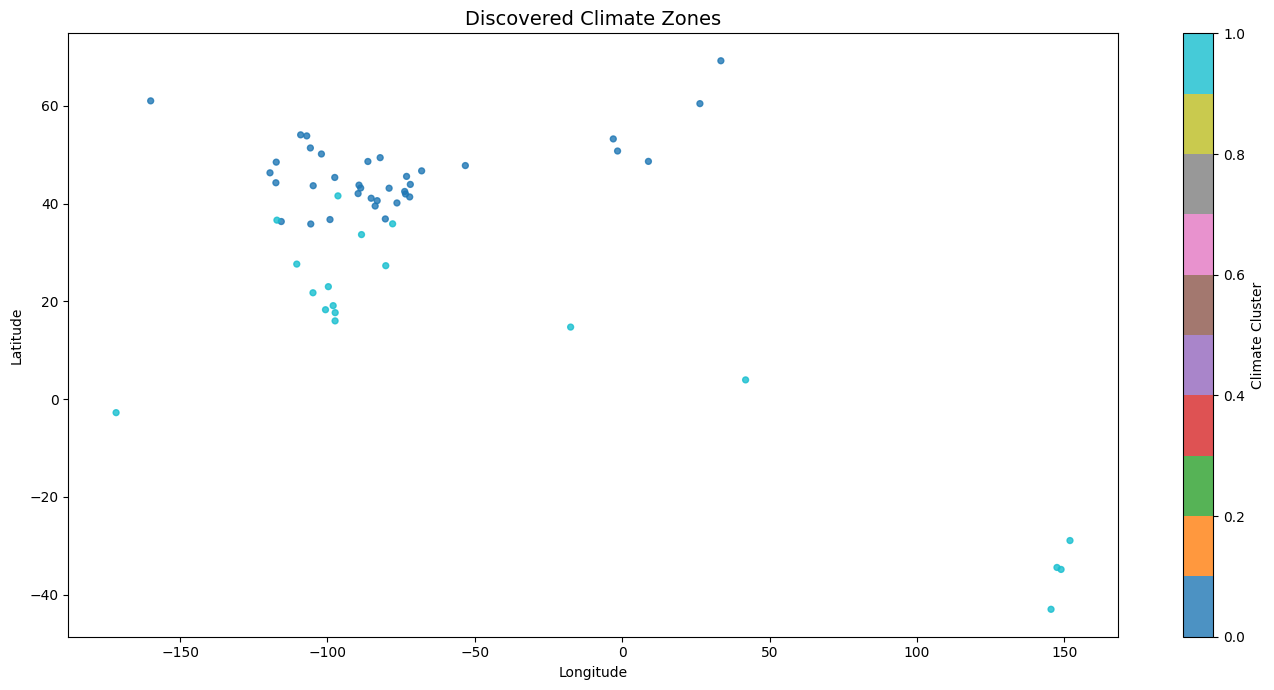

In [ ]:
viz_df = best_clusters.select("lat", "lon", "prediction").toPandas()

plt.figure(figsize=(14, 7))
scatter = plt.scatter(
    viz_df["lon"], viz_df["lat"],
    c=viz_df["prediction"], cmap="tab10", s=18, alpha=0.8
)
plt.colorbar(scatter, label="Climate Cluster")
plt.title("Discovered Climate Zones", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

Shapefile saved to /tmp/climate_clusters/climate_clusters.shp
Shapefile saved to /tmp/climate_clusters/climate_clusters.shp


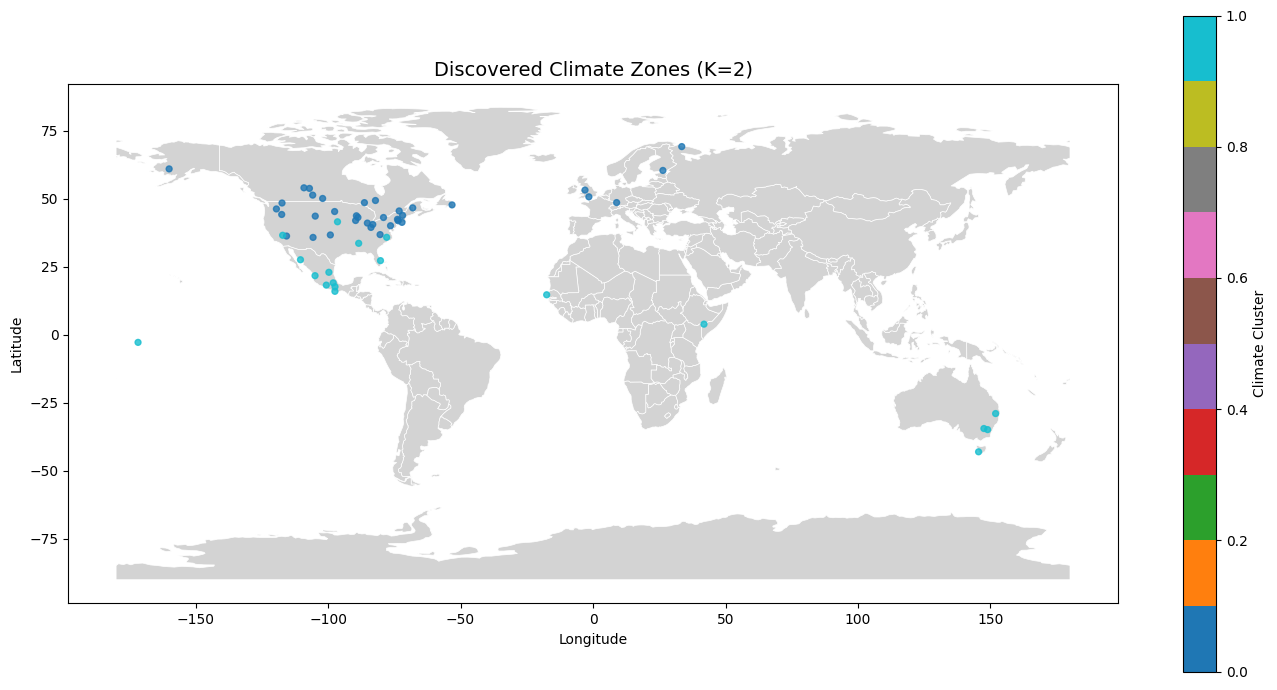

In [ ]:
!pip install geopandas --quiet

import os

os.makedirs("/tmp/climate_clusters", exist_ok=True)

SHAPEFILE_PATH = "/tmp/climate_clusters/climate_clusters.shp"
gdf.to_file(SHAPEFILE_PATH, driver="ESRI Shapefile")
print(f"Shapefile saved to {SHAPEFILE_PATH}")

import geopandas as gpd
from shapely.geometry import Point

viz_df = best_clusters.select("lat", "lon", "prediction").toPandas()

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    viz_df,
    geometry=[Point(lon, lat) for lon, lat in zip(viz_df["lon"], viz_df["lat"])],
    crs="EPSG:4326"  # standard WGS84 lat/lon
)

# Save to shapefile
SHAPEFILE_PATH = "/tmp/climate_clusters/climate_clusters.shp"
gdf.to_file(SHAPEFILE_PATH, driver="ESRI Shapefile")
print(f"Shapefile saved to {SHAPEFILE_PATH}")

import requests, io

# Download naturalearth_lowres directly
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

fig, ax = plt.subplots(figsize=(14, 7))
world.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.5)
gdf.plot(ax=ax, column="prediction", cmap="tab10", markersize=18,
         alpha=0.8, legend=True, legend_kwds={"label": "Climate Cluster"})
plt.title(f"Discovered Climate Zones (K={best_K})", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

## 14. Feature assembly + scaling + KMeans without Köppen-Like Proxy Variables

In [ ]:
def process_station(member_name):
    import pandas as pd
    import numpy as np
    import os

    path = os.path.join("/tmp/stations", member_name)
    df   = pd.read_csv(path)
    df   = df.dropna(subset=["LATITUDE", "LONGITUDE"])
    if df.empty:
        return None

    # Skip stations missing any required column entirely
    required = ["TMAX", "TMIN", "PRCP"]
    if any(c not in df.columns for c in required):
        return None

    # Skip stations where key columns are all NaN
    if df["TMAX"].isna().all() or df["TMIN"].isna().all() or df["PRCP"].isna().all():
        return None

    lat = float(df["LATITUDE"].iloc[0])
    lon = float(df["LONGITUDE"].iloc[0])

    annual_mean_temp   = float(df["TMAX"].mean())
    temp_seasonality   = float(df["TMAX"].std())
    warmest_month_temp = float(df["TMAX"].max())
    coldest_month_temp = float(df["TMIN"].min())

    annual_precip        = float(df["PRCP"].sum())
    precip_seasonality   = float(df["PRCP"].std())
    driest_month_precip  = float(df["PRCP"].min())
    wettest_month_precip = float(df["PRCP"].max())

    if any(np.isnan(v) for v in [
        annual_mean_temp, temp_seasonality,
        warmest_month_temp, coldest_month_temp,
        annual_precip, precip_seasonality,
        driest_month_precip, wettest_month_precip
    ]):
        return None

    return (
        member_name,
        lat, lon,
        annual_mean_temp, temp_seasonality,
        warmest_month_temp, coldest_month_temp,
        annual_precip, precip_seasonality,
        driest_month_precip, wettest_month_precip
    )

features_rdd = (
    stations_rdd
    .map(process_station)
    .filter(lambda x: x is not None)
)

features_df = spark.createDataFrame(
    features_rdd,
    [
        "station",
        "lat", "lon",
        "annual_mean_temp", "temp_seasonality",
        "warmest_month_temp", "coldest_month_temp",
        "annual_precip", "precip_seasonality",
        "driest_month_precip", "wettest_month_precip"
    ]
)

features_df.show(5)

+---------------+--------+---------+------------------+------------------+------------------+------------------+-------------+------------------+-------------------+--------------------+
|        station|     lat|      lon|  annual_mean_temp|  temp_seasonality|warmest_month_temp|coldest_month_temp|annual_precip|precip_seasonality|driest_month_precip|wettest_month_precip|
+---------------+--------+---------+------------------+------------------+------------------+------------------+-------------+------------------+-------------------+--------------------+
|ASN00041116.csv|-28.9231| 151.9306|205.09437644136952|55.853551333339375|             362.0|             -64.0|     893436.0| 66.76422690691636|                0.0|              1480.0|
|USC00264501.csv|36.32083|-115.6725| 137.8087912087912| 87.22469080076523|             322.0|            -261.0|      89360.0| 77.84126849632347|                0.0|              1748.0|
|FIE00142366.csv| 60.4331|  26.3667| 83.46782376502003|101.246964

In [ ]:
INPUT_COLS = [
    "annual_mean_temp", "temp_seasonality",
    "warmest_month_temp", "coldest_month_temp",
    "annual_precip", "precip_seasonality",
    "driest_month_precip", "wettest_month_precip"
]

assembler = VectorAssembler(inputCols=INPUT_COLS, outputCol="raw_features")
assembled = assembler.transform(features_df)

scaler  = StandardScaler(
    inputCol="raw_features", outputCol="features",
    withMean=True, withStd=True
)
dataset = scaler.fit(assembled).transform(assembled)

In [ ]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import builtins

evaluator = ClusteringEvaluator(featuresCol="features")
results   = {}

for K in range(2, 7):
    kmeans     = KMeans(k=K, seed=1, featuresCol="features")
    model      = kmeans.fit(dataset)
    clusters   = model.transform(dataset)
    silhouette = evaluator.evaluate(clusters)
    results[K] = {"model": model, "clusters": clusters, "silhouette": silhouette}
    print(f"K={K}  Silhouette={silhouette:.4f}")

best_K   = builtins.max(results, key=lambda k: results[k]["silhouette"])
clusters = results[best_K]["clusters"]
print(f"\nBest K={best_K}  Silhouette={results[best_K]['silhouette']:.4f}")

K=2  Silhouette=0.5519
K=3  Silhouette=0.3909
K=4  Silhouette=0.4509
K=5  Silhouette=0.4496
K=6  Silhouette=0.4442

Best K=2  Silhouette=0.5519


In [ ]:
from pyspark.sql.functions import avg, min, max, count

best_clusters = results[best_K]["clusters"]

summary = best_clusters.groupBy("prediction").agg(
    count("station").alias("num_stations"),

    avg("annual_mean_temp").alias("avg_mean_temp"),
    avg("warmest_month_temp").alias("avg_warmest_temp"),
    avg("coldest_month_temp").alias("avg_coldest_temp"),
    avg("temp_seasonality").alias("avg_temp_seasonality"),

    avg("annual_precip").alias("avg_annual_precip"),
    avg("wettest_month_precip").alias("avg_wettest_precip"),
    avg("driest_month_precip").alias("avg_driest_precip"),
    avg("precip_seasonality").alias("avg_precip_seasonality"),
).orderBy("prediction")

print(f"Cluster summary for best K={best_K}")
summary.show(truncate=False)

Cluster summary for best K=2
+----------+------------+------------------+------------------+-------------------+--------------------+------------------+------------------+-----------------+----------------------+
|prediction|num_stations|avg_mean_temp     |avg_warmest_temp  |avg_coldest_temp   |avg_temp_seasonality|avg_annual_precip |avg_wettest_precip|avg_driest_precip|avg_precip_seasonality|
+----------+------------+------------------+------------------+-------------------+--------------------+------------------+------------------+-----------------+----------------------+
|0         |18          |268.18836863532255|427.05555555555554|-15.722222222222221|51.3150417187042    |271662.27777777775|1943.0555555555557|0.0              |84.24563736254566     |
|1         |36          |127.59882315282147|370.5             |-339.8611111111111 |111.18558911079474  |293164.44444444444|980.4722222222222 |0.0              |55.17835685714179     |
+----------+------------+------------------+-------

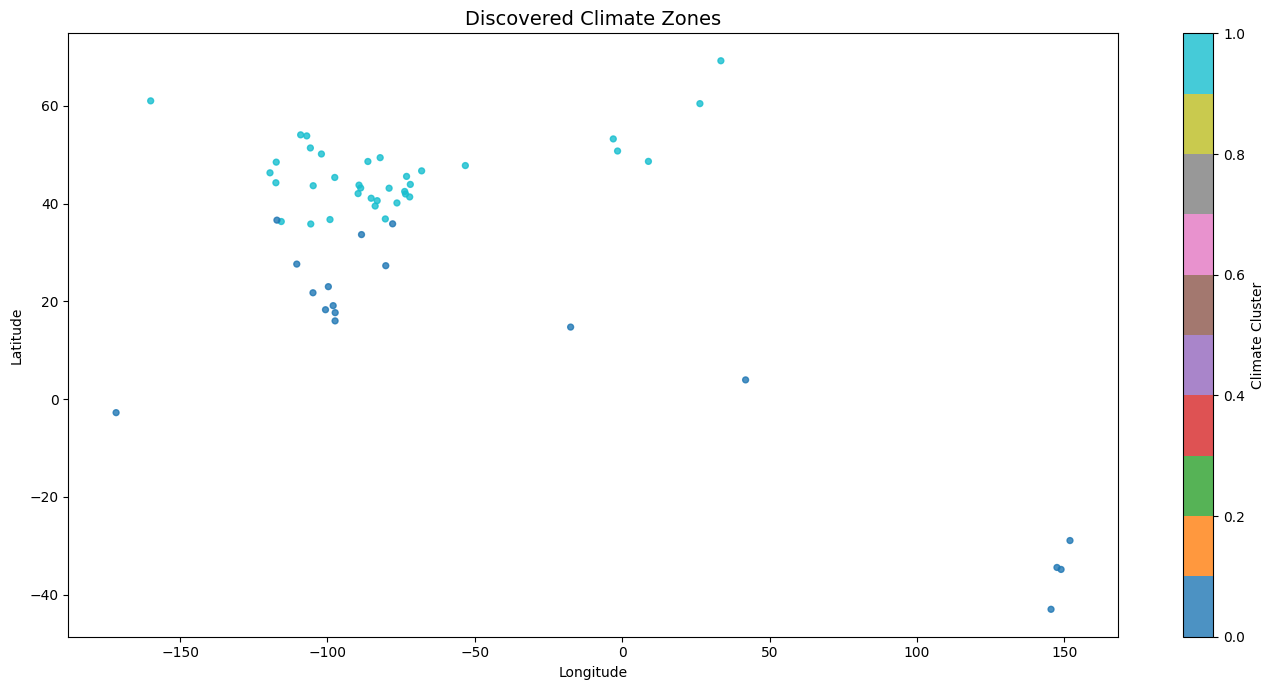

In [ ]:
viz_df = best_clusters.select("lat", "lon", "prediction").toPandas()

plt.figure(figsize=(14, 7))
scatter = plt.scatter(
    viz_df["lon"], viz_df["lat"],
    c=viz_df["prediction"], cmap="tab10", s=18, alpha=0.8
)
plt.colorbar(scatter, label="Climate Cluster")
plt.title("Discovered Climate Zones", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

Shapefile saved to /tmp/climate_clusters/climate_clusters.shp


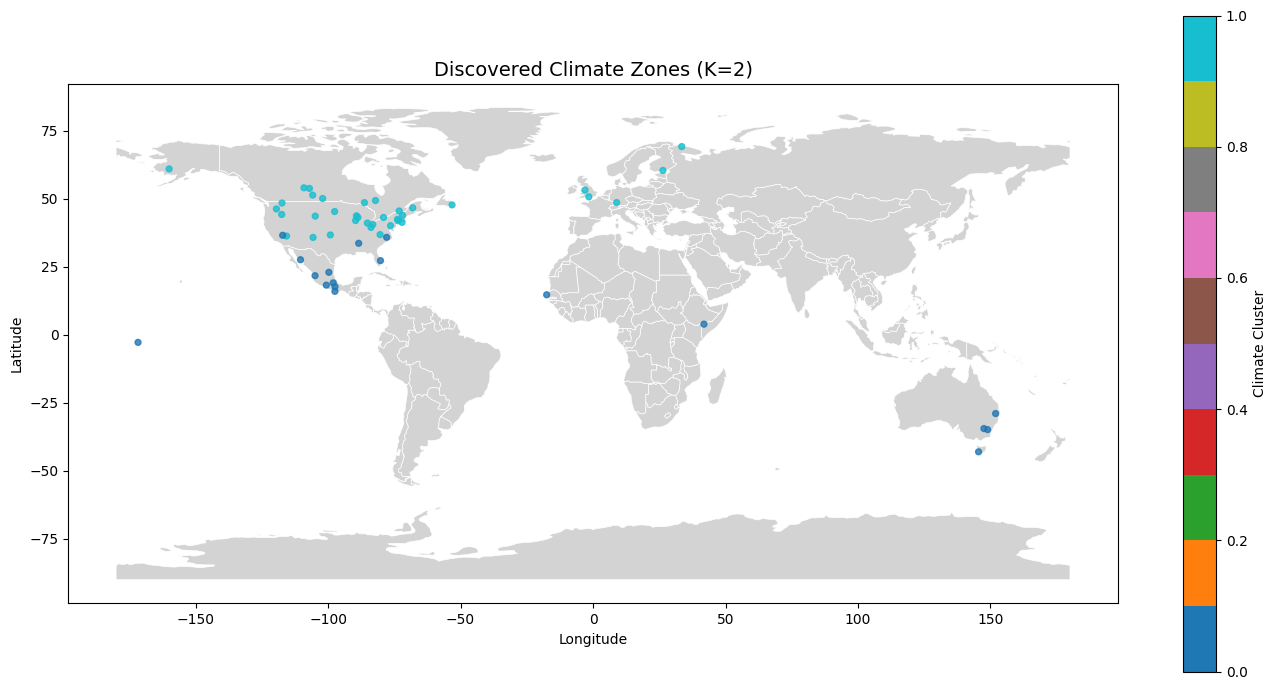

In [ ]:
!pip install geopandas --quiet

import geopandas as gpd
from shapely.geometry import Point

viz_df = best_clusters.select("lat", "lon", "prediction").toPandas()

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    viz_df,
    geometry=[Point(lon, lat) for lon, lat in zip(viz_df["lon"], viz_df["lat"])],
    crs="EPSG:4326"  # standard WGS84 lat/lon
)

# Save to shapefile
SHAPEFILE_PATH = "/tmp/climate_clusters/climate_clusters.shp"
gdf.to_file(SHAPEFILE_PATH, driver="ESRI Shapefile")
print(f"Shapefile saved to {SHAPEFILE_PATH}")

import requests, io

# Download naturalearth_lowres directly
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

fig, ax = plt.subplots(figsize=(14, 7))
world.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.5)
gdf.plot(ax=ax, column="prediction", cmap="tab10", markersize=18,
         alpha=0.8, legend=True, legend_kwds={"label": "Climate Cluster"})
plt.title(f"Discovered Climate Zones (K={best_K})", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

## END